# Consumption Forecast - Single Scenario by Country

## Purpose
This notebook generates annual heavy crude oil consumption forecasts for a specific country and scenario combination using time series analysis. It is designed to be called programmatically by a parent orchestration notebook.

## Execution Modes

**🔄 Automated Mode (Recommended)**
* This notebook is called by the main orchestration file: [04-Consumption - Looping All Selected Countries and Run All Scenarios](#notebook-897483376288297)
* The orchestration notebook automatically runs **all cells sequentially** and writes results to tables for multiple country-scenario combinations
* **No manual intervention required** - all forecasts are generated and saved automatically

**📊 Manual Mode (For Analysis & Debugging)**
* Run this notebook directly to test a single country-scenario combination
* Set the `country` and `scenario` widget parameters before running
* Final outputs are written to:
  * `workspace.gold.consumption_forecast_table_annual` (6-year forecasts with confidence intervals)
  * `workspace.gold.model_metrics` (model parameters and performance metrics)

## Key Features
* **Parameterized execution**: Receives `country` and `scenario` parameters via dbutils widgets
* **Scenario modeling**: Supports baseline forecasts and event-driven scenarios with exogenous variables
* **Special data handling**: Includes USSR/Russia consolidation logic (combines "Former U.S.S.R." pre-1992 data with "Russia" post-1992 data)
* **Time series methods**: Implements ARIMA (AutoRegressive Integrated Moving Average) models for annual data
* **Comprehensive analysis**: Performs stationarity testing (ADF test), differencing evaluation, and model optimization
* **Proxy methodology**: Uses residual fuel oil consumption as a proxy indicator for heavy crude consumption patterns

## Workflow
1. **Load and validate input parameters** (country and scenario) - Cell 2
2. **Sanitize names** for database table creation - Cell 4
3. **Load exogenous variables** for non-baseline scenarios from `gold.exogenous_variables` - Cell 5
4. **Load historical consumption data** from `gold.heavy_consumption_timeseries_annual` - Cell 6
   * Special handling: Combines Former U.S.S.R. + Russia data for Russia
5. **Align exogenous variables** with time series dates (monthly → annual conversion) - Cell 7
6. **Perform exploratory data analysis** - Visualization of consumption trends - Cell 10
7. **Test for stationarity** - Augmented Dickey-Fuller (ADF) test on original and differenced data - Cells 12, 14, 16
8. **Optimize ARIMA model parameters** - Grid search over p and q parameters with convergence validation - Cell 25
9. **Generate 6-year annual forecast (2025-2030)** - Cells 27+
10. **Write results** to gold layer tables

## Data Sources
* **Historical consumption**: `workspace.gold.heavy_consumption_timeseries_annual` - Annual heavy crude consumption by country
* **Exogenous variables**: `workspace.gold.exogenous_variables` - Monthly event indicators for scenario modeling (converted to annual proportions)

## Output
* **Annual forecasts**: `workspace.gold.consumption_forecast_table_annual` - 6-year forecast with confidence intervals
  * Schema: `Country`, `Scenario`, `Date`, `Total_crude`, `Total_Lower_Bound`, `Total_Upper_Bound`, `Total_crude_forecast`
* **Model performance metrics**: `workspace.gold.model_metrics` - Winning model parameters (p, d, q), AIC, and exogenous variable coefficient for each country-scenario combination

## Model Configuration
* **Differencing**: d=1 (first-order differencing to achieve stationarity)
* **Seasonality**: None (annual data has no seasonal component: D=0, s=0)
* **Parameter search space**: p ∈ [0,2], q ∈ [0,2]
* **Trend**: Constant term included
* **Validation**: 3-year test set holdout for model evaluation


In [0]:
# Receive parameters from calling notebook
dbutils.widgets.text("country", "")
dbutils.widgets.text("scenario", "")

country = dbutils.widgets.get("country")
scenario = dbutils.widgets.get("scenario")

# Validate that parameters were passed
if not country or not scenario:
    raise ValueError(f"Missing required parameters! country='{country}', scenario='{scenario}'. This notebook must be called with both parameters.")

print(f"Running forecast for:")
print(f"  Country: {country}")
print(f"  Scenario: {scenario}")

Running forecast for:
  Country: Canada
  Scenario: COVID Shutdowns


In [0]:
# Ensure consumption_forecast_table_annual exists with the correct schema
spark.sql("""
    CREATE TABLE IF NOT EXISTS workspace.gold.consumption_forecast_table_annual (
        Country STRING,
        Scenario STRING,
        Date TIMESTAMP,
        Total_crude DOUBLE,
        Total_Lower_Bound DOUBLE,
        Total_Upper_Bound DOUBLE,
        Total_crude_forecast DOUBLE        
    )
    USING DELTA
""")

print("✓ consumption_forecast_table_annual ready")

✓ consumption_forecast_table_annual ready


In [0]:
import re

def sanitize_table_name(name):
    """
    Sanitize a string to be a valid SQL table name component.
    - Converts to lowercase
    - Replaces spaces, hyphens, and all non-alphanumeric characters with underscores
    - Removes consecutive underscores
    - Removes leading/trailing underscores
    """
    # Convert to lowercase
    name = name.lower()
    # Replace all non-alphanumeric characters (including spaces, hyphens, parentheses, etc.) with underscores
    name = re.sub(r'[^a-z0-9]+', '_', name)
    # Remove leading/trailing underscores
    name = name.strip('_')
    return name

# Sanitize country and scenario for use in table names
country_sanitized = sanitize_table_name(country)
scenario_sanitized = sanitize_table_name(scenario)

print(f"Sanitized names for table creation:")
print(f"  Country: '{country}' → '{country_sanitized}'")
print(f"  Scenario: '{scenario}' → '{scenario_sanitized}'")

Sanitized names for table creation:
  Country: 'Canada' → 'canada'
  Scenario: 'COVID Shutdowns' → 'covid_shutdowns'


In [0]:
# Initialize exogenous_variables as None (will be loaded for non-Baseline scenarios)
exogenous_variables_full = None

if scenario != 'Baseline scenario':
    #load the exogenous variables from workspace.gold.exogenous_variables into an array
    #get the row and convert to list, keeping only date columns (format: YYYY-MM)
    row = spark.sql(f"SELECT * FROM gold.exogenous_variables WHERE Country = '{country}' AND Description = '{scenario}'").collect()[0]
    
    # Get column names to identify date columns (format: YYYY-MM like "1973-01")
    all_columns = spark.sql(f"SELECT * FROM gold.exogenous_variables LIMIT 0").columns
    date_columns = [col for col in all_columns if col and '-' in col and col[0].isdigit()]
    
    # Extract only the values from date columns, in order
    exogenous_variables_raw = [row[col] if row[col] is not None else 0 for col in date_columns]
    
    # Add 6 years worth of monthly 1s to the end of the array for future forecast (2025-2030)
    # 6 years × 12 months = 72 monthly values
    exogenous_variables_raw.extend([1]*(6*12))
    
    # Get the start date from exogenous_variables table (first date column name)
    exog_start_date = '1973-01'
    
    # Store the full exogenous variables array for later alignment
    exogenous_variables_full = exogenous_variables_raw
    
    print(f"Loaded {len(exogenous_variables_full)} exogenous variable values (1973-01 to 6 years beyond data)")


Loaded 710 exogenous variable values (1973-01 to 6 years beyond data)


In [0]:
#If country is Russia, there is no data before 1992, the data before 1992 is under the country name "Former U.S.S.R.". So, for Russia, we need to load the data for "Former U.S.S.R.", combine the two datasets, and name the country as "Russia"
if country == 'Russia':
    df = spark.sql(f"""
        SELECT 'Russia' AS Country, Year, value AS `Oil_Consumption`
        FROM gold.heavy_consumption_timeseries_annual
        WHERE Country = 'Former U.S.S.R.'
        UNION ALL
        SELECT 'Russia' AS Country, Year, value AS `Oil_Consumption`
        FROM gold.heavy_consumption_timeseries_annual
        WHERE Country = 'Russia'
        ORDER BY Year ASC
    """)
    df_pd = df.toPandas()
# else, load annual consumption data as normal for all other countries
else:
    df = spark.sql(f"""
        SELECT Country, Year, value AS `Oil_Consumption`
        FROM gold.heavy_consumption_timeseries_annual
        WHERE Country = '{country}'
        ORDER BY Year ASC
    """)
    df_pd = df.toPandas()

In [0]:
# Align exogenous variables with the time series data dates
if scenario != 'Baseline scenario' and exogenous_variables_full is not None:
    import pandas as pd
    from dateutil.relativedelta import relativedelta
    
    # Get the first year in our time series
    ts_start_year = int(df_pd['Year'].iloc[0])
    exog_start_year = 1973
    
    # Calculate the number of years to skip
    years_diff = ts_start_year - exog_start_year
    
    # CRITICAL FIX: exogenous_variables_full contains MONTHLY data (12 values per year)
    # We need to convert monthly binary values to ANNUAL values
    # Strategy: For each year, calculate the proportion of months with event=1 (0.0 to 1.0)
    
    # Calculate months to skip
    months_diff = years_diff * 12
    
    # Total years needed: historical data + 6 forecast years (2025-2030)
    total_years_needed = len(df_pd) + 6
    
    # Extract monthly values from start year onwards, converting None to 0
    monthly_values = [0 if v is None else v for v in exogenous_variables_full[months_diff:]]
    
    # Convert monthly to annual by aggregating every 12 months
    exogenous_variables = []
    for year_idx in range(total_years_needed):
        start_month = year_idx * 12
        end_month = start_month + 12
        
        # Get 12 months for this year
        if end_month <= len(monthly_values):
            year_months = monthly_values[start_month:end_month]
        else:
            # If we run out of monthly data, pad with 1s (assume event continues for forecast)
            year_months = monthly_values[start_month:]
            year_months.extend([1] * (12 - len(year_months)))
        
        # Calculate proportion: number of months with event=1 divided by 12
        # This gives 0.0 (no event) to 1.0 (event all year)
        year_value = sum(year_months) / 12.0
        exogenous_variables.append(year_value)
    
    print(f"Aligned exogenous variables (monthly → annual):")
    print(f"  Time series starts: {ts_start_year}")
    print(f"  Skipped {years_diff} years ({months_diff} months) from exog data")
    print(f"  Aligned length: {len(exogenous_variables)} years (matching {len(df_pd)} historical + 6 forecast)")
    print(f"  First 10 values: {[f'{v:.3f}' for v in exogenous_variables[:10]]}")
    print(f"  Last 10 values: {[f'{v:.3f}' for v in exogenous_variables[-10:]]}")
    print(f"  Non-zero years: {sum(1 for v in exogenous_variables if v > 0)}")
    
    # Show which years have the event
    event_years = [(ts_start_year + i, f'{v:.3f}') for i, v in enumerate(exogenous_variables) if v > 0]
    if event_years:
        print(f"  Years with event (>0): {event_years[:10]}...")  # Show first 10
else:
    exogenous_variables = None
    print("No exogenous variables (Baseline scenario)")

Aligned exogenous variables (monthly → annual):
  Time series starts: 1980
  Skipped 7 years (84 months) from exog data
  Aligned length: 51 years (matching 45 historical + 6 forecast)
  First 10 values: ['0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000']
  Last 10 values: ['0.000', '0.000', '0.000', '0.000', '0.000', '0.833', '1.000', '1.000', '1.000', '1.000']
  Non-zero years: 6
  Years with event (>0): [(2020, '0.333'), (2026, '0.833'), (2027, '1.000'), (2028, '1.000'), (2029, '1.000'), (2030, '1.000')]...


In [0]:
import time
from datetime import datetime

# Record start time
notebook_start_time = time.time()
print(f"Notebook execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook execution started at: 2026-08-27 10:06:18


View the data

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


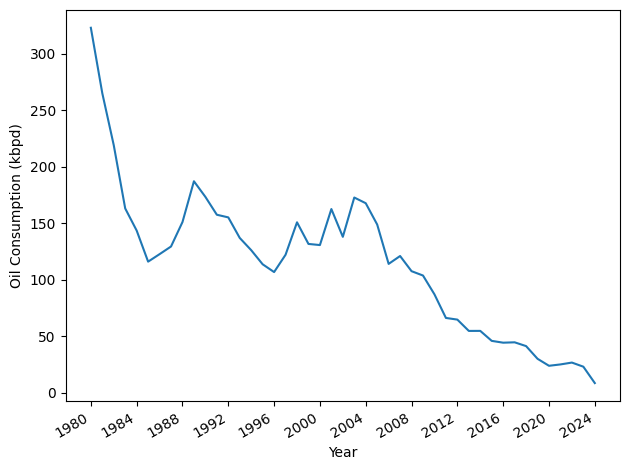

In [0]:
# uncomment if library installation required
%pip install statsmodels 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

from statsmodels.tsa.seasonal import seasonal_decompose, STL

#plot the data
fig, ax = plt.subplots()

ax.plot(df_pd.Year, df_pd.Oil_Consumption)
ax.set_xlabel('Year')
ax.set_ylabel('Oil Consumption (kbpd)')

# Generate dynamic tick labels from actual data
n_ticks = 10
tick_positions = np.arange(0, len(df_pd), max(1, len(df_pd)//n_ticks))
tick_labels = [int(df_pd['Year'].iloc[min(i, len(df_pd)-1)]) for i in tick_positions]
plt.xticks(tick_positions, tick_labels)

fig.autofmt_xdate()
plt.tight_layout()

 Test for stationarity

In [0]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
ADF_result = adfuller(df_pd["Oil_Consumption"])
print("Augmented Dickey-Fuller test:")
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

Augmented Dickey-Fuller test:
ADF Statistic: -3.208402892325276
p-value: 0.019503410053868537


With a p-value smaller than 0.05, we can reject the null hypothesis stating that our time series is not stationary, though it is vary close to 0.05. Let's plot the comparison between the original and differenced data to see if we need to difference it.

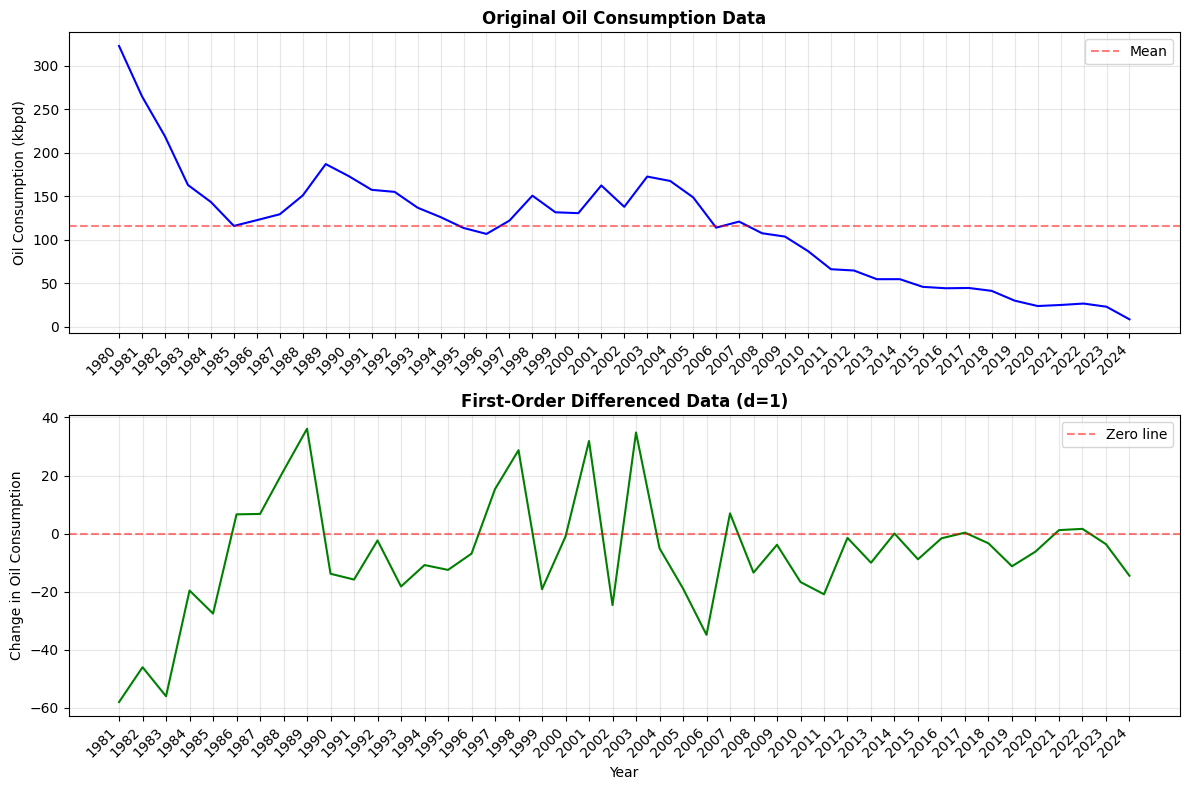

COMPARISON: Original vs Differenced Data

Original Data: Mean = 115.47, Std Dev = 65.83, Range = [8.35, 323.00]
Differenced Data: Mean = -7.15, Std Dev = 20.39, Range = [-58.00, 36.12]


In [0]:
# Compare original vs differenced data
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

diff_data = df_pd['Oil_Consumption'].diff().dropna()
diff_years = df_pd['Year'].iloc[1:] # skip the first year as it's not used in differencing

# Original data
axes[0].plot(df_pd['Year'], df_pd['Oil_Consumption'], 'b-', linewidth=1.5)
axes[0].axhline(y=df_pd['Oil_Consumption'].mean(), color='r', linestyle='--', alpha=0.5, label='Mean')
axes[0].set_title('Original Oil Consumption Data', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Oil Consumption (kbpd)', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Differenced data
axes[1].plot(diff_years, diff_data, 'g-', linewidth=1.5)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero line')
axes[1].set_title('First-Order Differenced Data (d=1)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=10)
axes[1].set_ylabel('Change in Oil Consumption', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# rotate x-axis labels
for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"{'=' * 60}\nCOMPARISON: Original vs Differenced Data\n{'=' * 60}")
print(f"\nOriginal Data: Mean = {df_pd['Oil_Consumption'].mean():.2f}, Std Dev = {df_pd['Oil_Consumption'].std():.2f}, Range = [{df_pd['Oil_Consumption'].min():.2f}, {df_pd['Oil_Consumption'].max():.2f}]")
print(f"Differenced Data: Mean = {diff_data.mean():.2f}, Std Dev = {diff_data.std():.2f}, Range = [{diff_data.min():.2f}, {diff_data.max():.2f}]")

From the plots:
- Original data shows a clear downward trend
- Differenced data (d=1) removes the trend and centers around zero
- If differenced, data looks more 'stationary' (fluctuates around zero), using d=1 might improve the ARIMA model even though ADF test said "d=0"

In [0]:
dy = np.diff(df_pd["Oil_Consumption"])

# Augmented Dickey-Fuller test
ADF_result = adfuller(dy)
print("Augmented Dickey-Fuller test:")
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

Augmented Dickey-Fuller test:
ADF Statistic: -5.187267309852579
p-value: 9.333869790078434e-06


Now with the promising small p-value, we can safely reject the null hypothesis stating that our time series is not stationary. Differencing once seems to do a great job getting it stationary, so moving forward we'll use d=1 for the ARIMA.

Next is to build the list of possible parameter combinations.

In [0]:

from itertools import product

ps = range(0, 6, 1)
qs = range(0, 6, 1)
Ps = [0]    #Doing ARIMA, so set to 0
Qs = [0]

d = 1   #difference it once to make it more stationary
D = 0   #again, doing ARIMA, don't need this
s = 0  #denotes frequency. Annual data has no seasonal component, so s=0

ARIMA_order_list = list(product(ps, qs, Ps, Qs))
ARIMA_order_list


[(0, 0, 0, 0),
 (0, 1, 0, 0),
 (0, 2, 0, 0),
 (0, 3, 0, 0),
 (0, 4, 0, 0),
 (0, 5, 0, 0),
 (1, 0, 0, 0),
 (1, 1, 0, 0),
 (1, 2, 0, 0),
 (1, 3, 0, 0),
 (1, 4, 0, 0),
 (1, 5, 0, 0),
 (2, 0, 0, 0),
 (2, 1, 0, 0),
 (2, 2, 0, 0),
 (2, 3, 0, 0),
 (2, 4, 0, 0),
 (2, 5, 0, 0),
 (3, 0, 0, 0),
 (3, 1, 0, 0),
 (3, 2, 0, 0),
 (3, 3, 0, 0),
 (3, 4, 0, 0),
 (3, 5, 0, 0),
 (4, 0, 0, 0),
 (4, 1, 0, 0),
 (4, 2, 0, 0),
 (4, 3, 0, 0),
 (4, 4, 0, 0),
 (4, 5, 0, 0),
 (5, 0, 0, 0),
 (5, 1, 0, 0),
 (5, 2, 0, 0),
 (5, 3, 0, 0),
 (5, 4, 0, 0),
 (5, 5, 0, 0)]

Now that we have our parameter array, define the SARIMA optimizer

In [0]:
#required imports
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [0]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def optimize_SARIMA(
    endog: Union[pd.Series, list],
    order_list: list,
    d: int,
    D: int,
    s: int,
    exog: Union[pd.Series, list, None] = None
) -> pd.DataFrame:

    results = []

    for order in tqdm_notebook(order_list):

        p, q, P, Q = order

        try:
            with warnings.catch_warnings(record=True) as caught_warnings:
                warnings.simplefilter("always")

                model = SARIMAX(
                    endog,
                    exog=exog,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    simple_differencing=False,
                    trend="c"
                )

                fit = model.fit(disp=False, maxiter=500)

            # Did statsmodels optimizer say it converged?
            mle_converged = fit.mle_retvals.get("converged", False)

            # Did fitting raise a convergence warning?
            had_convergence_warning = any(
                issubclass(w.category, ConvergenceWarning)
                for w in caught_warnings
            )

            # Final status: only trust it if both are okay
            usable = mle_converged and not had_convergence_warning

            results.append({
                "(p,q,P,Q)": order,
                "order": (p, d, q),
                "seasonal_order": (P, D, Q, s),
                "AIC": fit.aic,
                "mle_converged": mle_converged,
                "convergence_warning": had_convergence_warning,
                "usable": usable
            })

        except Exception as e:
            results.append({
                "(p,q,P,Q)": order,
                "order": (p, d, q),
                "seasonal_order": (P, D, Q, s),
                "AIC": None,
                "mle_converged": False,
                "convergence_warning": True,
                "usable": False,
                "error": str(e)
            })

    result_df = pd.DataFrame(results)

    result_df = result_df.sort_values(
        by="AIC",
        ascending=True,
        na_position="last"
    ).reset_index(drop=True)

    return result_df

## ARIMA model

In [0]:
#create the test set, which is the last 3 years of the data
test = df_pd.iloc[-3:]

# display(test)

##Now define the range of possible parameter values for the ARIMA

In [0]:
ps = range(0, 3, 1)
qs = range(0, 3, 1)
Ps = [0]  # No seasonality in annual data
Qs = [0]  # No seasonality in annual data

ARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df_pd['Oil_Consumption'].iloc[:-3]

# Prepare exog for training (if available)
if exogenous_variables is not None:
    exog_train = exogenous_variables[:len(train)]
else:
    exog_train = None

d = 1
D = 0

ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s, exog=exog_train)
display(ARIMA_result_df)

/home/spark-9377e451-9913-4e69-bf87-73/.ipykernel/93/command-8195117642548345-1708508434:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/9 [00:00<?, ?it/s]

"(p,q,P,Q)",order,seasonal_order,AIC,mle_converged,convergence_warning,usable
"List(2, 0, 0, 0)","List(2, 1, 0)","List(0, 0, 0, 0)",368.80060103301616,true,false,true
"List(1, 0, 0, 0)","List(1, 1, 0)","List(0, 0, 0, 0)",369.0980907227596,true,false,true
"List(0, 2, 0, 0)","List(0, 1, 2)","List(0, 0, 0, 0)",369.7056646869491,true,false,true
"List(1, 1, 0, 0)","List(1, 1, 1)","List(0, 0, 0, 0)",369.73059565186685,true,false,true
"List(1, 2, 0, 0)","List(1, 1, 2)","List(0, 0, 0, 0)",369.9516288247637,true,false,true
"List(0, 1, 0, 0)","List(0, 1, 1)","List(0, 0, 0, 0)",370.494861162489,true,false,true
"List(2, 1, 0, 0)","List(2, 1, 1)","List(0, 0, 0, 0)",370.7837928703349,true,false,true
"List(0, 0, 0, 0)","List(0, 1, 0)","List(0, 0, 0, 0)",371.1375919141204,true,false,true
"List(2, 2, 0, 0)","List(2, 1, 2)","List(0, 0, 0, 0)",374.00337848819566,true,false,true


In [0]:
# Filter for usable models first (converged without warnings)
usable_arima = ARIMA_result_df[ARIMA_result_df['usable'] == True]

if len(usable_arima) == 0:
    print("WARNING: No usable ARIMA models found. Using best model anyway, but check convergence.")
    best_model = ARIMA_result_df.iloc[0]
else:
    best_model = usable_arima.iloc[0]

p = best_model['order'][0]
q = best_model['order'][2]
P = best_model['seasonal_order'][0]
Q = best_model['seasonal_order'][2]

#print the parameters
print(f"Selected ARIMA model: p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q}")
print(f"AIC: {best_model['AIC']:.2f}")
print(f"Usable: {best_model['usable']}")

#print a warning if the model is at the top range of parameters (p=2, q=2)
if (p == 2) and (q == 2):
    print("WARNING: Model is at the top range of parameters (p=2, q=2). Consider running a larger gridsearch.")


Selected ARIMA model: p=2, d=1, q=0, P=0, D=0, Q=0
AIC: 368.80
Usable: True


The model that performed the best is listed above and the parameters have been assigned to variables.

Move forward with this model, analyzing the residuals.

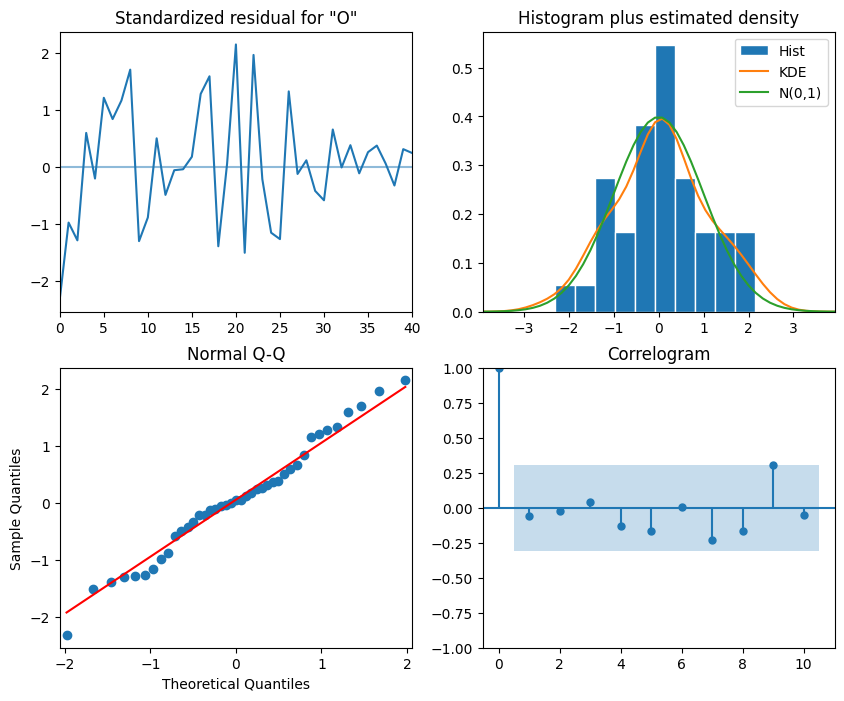

In [0]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
ARIMA_model = SARIMAX(
    train, 
    exog=exog_train, 
    order=(p,d,q), 
    seasonal_order=(P,D,Q,s), 
    simple_differencing=False, 
    trend="c"
)

ARIMA_model_fit = ARIMA_model.fit(disp=False, maxiter=500)

# print(ARIMA_model_fit.summary())

ARIMA_model_fit.plot_diagnostics(figsize=(10,8))
plt.show()

Based on the above diagnostics plots: 

The residuals fluctuate around zero with no clear trend or pattern. The distribution of residuals approx a normal distribution, and has a rough straight line in the QQ plot confirming normality.
The ACF (Autocorrelation Function) plot shows no significant autocorrelation beyond lag 0 (majority within bands with lag 10 being marginally outside the band), indicating the residuals are mostly uncorrelated.

Overall, the residuals resemble white noise, which is exactly what we want. This validates that our ARIMA model has captured the meaningful patterns in the data.
<br><br>
---

Next, the Ljung-Box test on the residuals to make sure that they are independent and uncorrelated.

**Null Hypothesis**: The residuals are independently distributed (no autocorrelation) <br>
Alternative hypothesis: The residuals exhibit autocorrelation

In [0]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = ARIMA_model_fit.resid

lb_test = acorr_ljungbox(
    residuals,
    lags=np.arange(1, 11, 1),
    return_df=True
)

print(lb_test)

     lb_stat  lb_pvalue
1   0.911213   0.339793
2   1.077453   0.583491
3   1.310157   0.726723
4   1.311144   0.859482
5   1.397076   0.924633
6   1.538462   0.956899
7   1.539542   0.980909
8   1.586999   0.991167
9   2.378034   0.983986
10  2.737875   0.986938


All p-values are well above 0.05, which means we **fail to reject the null hypothesis**. This indicates the residuals **are NOT autocorrelated**.

## Model Training Strategy

**Two-stage approach:**

1. **Model Selection (Cells 34-44):** Train ARIMA and Prophet on the **training set only** (all data except last 3 years), then evaluate on the test set to select the best model.

2. **Final Forecast (Cells 45-52):** Retrain BOTH models on the **full dataset** (all historical data) before generating the 6-year consumption forecast. This ensures both models use all available information for the final forecast.

This approach ensures:
* Fair model comparison (both use same training data)
* Maximum data utilization for consumption forecasts
* Consistent coefficient extraction (from full-data model)

## Create a Prophet model for comparison

In [0]:
%pip install prophet

from prophet import Prophet

# Prepare data for Prophet using ONLY the training set (consistent with SARIMA)
# This ensures fair comparison - both models trained on same data
train_size = len(df_pd) - 3
prophet_df = df_pd[['Year', 'Oil_Consumption']].iloc[:train_size].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'].astype(str) + '-01-01')

# Add exogenous variable to Prophet training data (if available)
if exogenous_variables is not None:
    prophet_df['exog_scenario'] = exogenous_variables[:train_size]

# Initialize and fit Prophet model
print("Training Prophet model...")
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # Oil production often has multiplicative seasonality
    changepoint_prior_scale=0.05  # Controls flexibility of trend
)

# Add exogenous regressor if available
if exogenous_variables is not None:
    model.add_regressor('exog_scenario')
    print("Added exogenous scenario variable as regressor")

model.fit(prophet_df)
print("Prophet model trained successfully!")

# Create future dataframe for 9 years (3 for test set + 6 for 6-year forecast)
# Prophet was trained on training set, so needs to forecast through test period AND 6 years beyond
future = model.make_future_dataframe(periods=9, freq='YS')

# Add exogenous variable to future dataframe (if available)
if exogenous_variables is not None:
    # Need to provide exog values for: training period + test period (3) + forecast period (6)
    # Pad exogenous_variables if needed to match future length
    exog_for_future = list(exogenous_variables) + [exogenous_variables[-1]] * (len(future) - len(exogenous_variables))
    future['exog_scenario'] = exog_for_future[:len(future)]

# Make predictions
print("Generating 6-year forecast...")
forecast = model.predict(future)

print(f"Forecast generated from {forecast['ds'].min()} to {forecast['ds'].max()}")

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Training Prophet model...
Added exogenous scenario variable as regressor


10:06:44 - cmdstanpy - INFO - Chain [1] start processing
10:06:44 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!
Generating 6-year forecast...
Forecast generated from 1980-01-01 00:00:00 to 2030-01-01 00:00:00


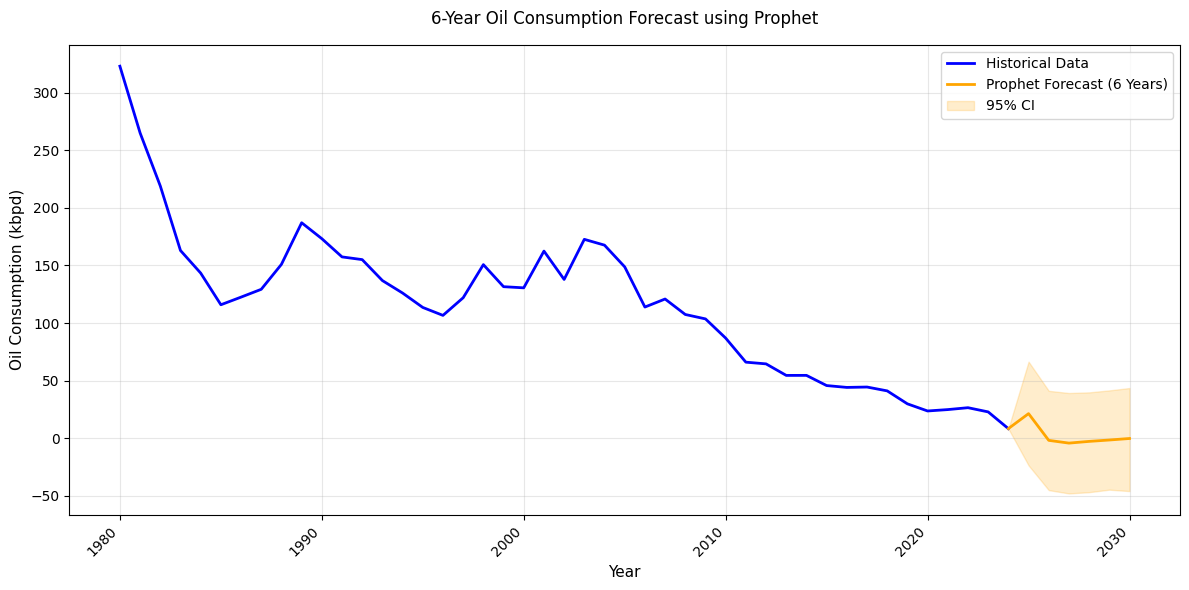


Forecast Summary:
Last historical value: 8.35 kbpd (2024)
Forecasted value in 6 years: -0.23 kbpd (2030)
Change: -102.73%


In [0]:
# Plot Prophet forecast
fig, ax = plt.subplots(figsize=(12, 6))

full_hist_df = df_pd[['Year', 'Oil_Consumption']].copy()
full_hist_df['Year'] = pd.to_datetime(full_hist_df['Year'].astype(str) + '-01-01')
last_full_year = pd.to_datetime(str(int(df_pd['Year'].iloc[-1])) + '-01-01')

# Historical data
ax.plot(full_hist_df['Year'], full_hist_df['Oil_Consumption'], label='Historical Data', color='blue', linewidth=2)

# Forecast with connection point (using forecast from cell 44)
prophet_forecast = model.predict(future)
forecast_future = prophet_forecast[prophet_forecast['ds'] > last_full_year].copy()

# Create connection point from last historical value
last_hist_value = full_hist_df['Oil_Consumption'].iloc[-1]
last_hist_point = pd.DataFrame({
    'ds': [last_full_year],
    'yhat': [last_hist_value],
    'yhat_lower': [last_hist_value],
    'yhat_upper': [last_hist_value]
})
forecast_conn = pd.concat([last_hist_point, forecast_future], ignore_index=True)

ax.plot(forecast_conn['ds'], forecast_conn['yhat'], label='Prophet Forecast (6 Years)', color='orange', linewidth=2)
ax.fill_between(forecast_conn['ds'], forecast_conn['yhat_lower'], forecast_conn['yhat_upper'], color='orange', alpha=0.2, label='95% CI')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Oil Consumption (kbpd)', fontsize=11)
ax.set_title('6-Year Oil Consumption Forecast using Prophet', fontsize=12, pad=15)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nForecast Summary:")
print(f"Last historical value: {full_hist_df['Oil_Consumption'].iloc[-1]:.2f} kbpd ({full_hist_df['Year'].iloc[-1].strftime('%Y')})")
print(f"Forecasted value in 6 years: {forecast_future['yhat'].iloc[-1]:.2f} kbpd ({forecast_future['ds'].iloc[-1].strftime('%Y')})")
print(f"Change: {((forecast_future['yhat'].iloc[-1] / full_hist_df['Oil_Consumption'].iloc[-1]) - 1) * 100:.2f}%")

In [0]:
# Calculate dynamic indices for naive forecast (3 years before test set)
train_end_idx = len(df_pd) - 3
naive_start_idx = train_end_idx - 3
naive_end_idx = train_end_idx

# Naive forecast using previous 3 years as forecast for next 3 years
test['naive_baseline'] = df_pd['Oil_Consumption'].iloc[naive_start_idx:naive_end_idx].values

# SARIMA predictions for test period using dynamic indices
test_start_idx = len(df_pd) - 3
test_end_idx = len(df_pd)

# Prepare exog for test period
if exogenous_variables is not None:
    exog_test = exogenous_variables[len(train):len(train)+3]
    ARIMA_pred = ARIMA_model_fit.get_prediction(test_start_idx, test_end_idx - 1, exog=exog_test)
else:
    ARIMA_pred = ARIMA_model_fit.get_prediction(test_start_idx, test_end_idx - 1)

test['ARIMA_pred'] = ARIMA_pred.predicted_mean.values

# Extract Prophet predictions for the test period
test_years = pd.to_datetime(test['Year'].astype(str) + '-01-01')
prophet_test_pred = forecast[forecast['ds'].isin(test_years)]['yhat'].values
test['Prophet_pred'] = prophet_test_pred

/home/spark-9377e451-9913-4e69-bf87-73/.ipykernel/93/command-8195117642548360-1514638811:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_baseline'] = df_pd['Oil_Consumption'].iloc[naive_start_idx:naive_end_idx].values
/home/spark-9377e451-9913-4e69-bf87-73/.ipykernel/93/command-8195117642548360-1514638811:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ARIMA_pred'] = ARIMA_pred.predicted_mean.values
/home/spark-9377e451-9913-4e69-bf87-73/.ipykernel/93/command-8195117642548360-1514638811

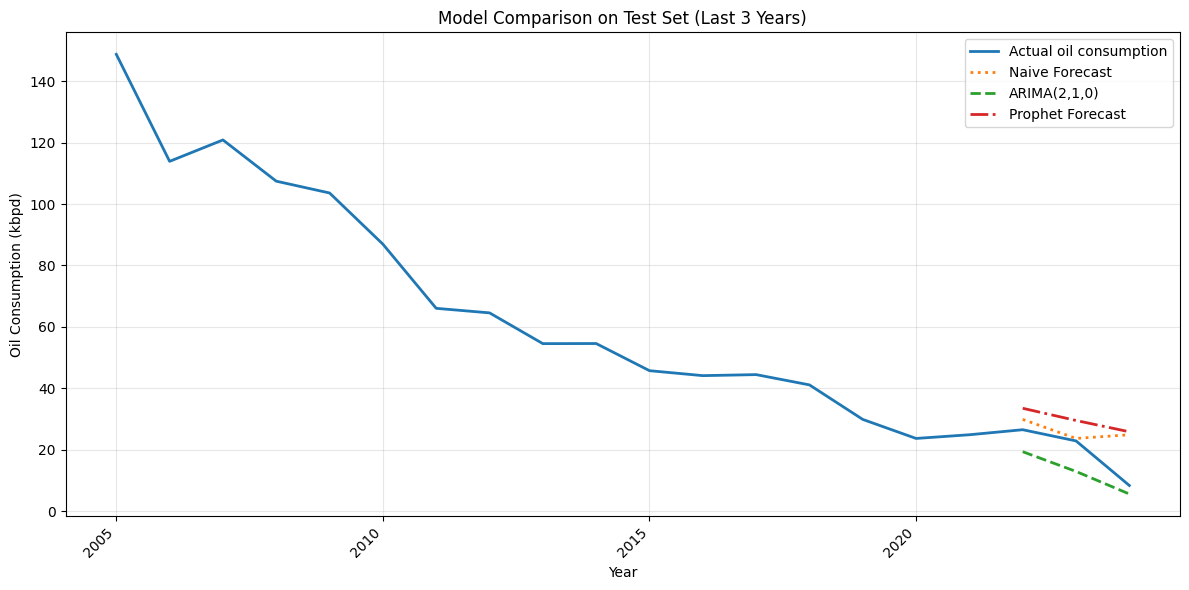

In [0]:
#now plot test and train (the last 20 years for visibility)
plot_df = df_pd.iloc[-min(20, len(df_pd)):]

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(plot_df['Year'], plot_df['Oil_Consumption'], label='Actual oil consumption', linewidth=2)
ax.plot(test['Year'], test['naive_baseline'], label='Naive Forecast', linestyle=':', linewidth=2)
ax.plot(test['Year'], test['ARIMA_pred'], label=f'ARIMA({p},{d},{q})', linestyle='--', linewidth=2)
ax.plot(test['Year'], test['Prophet_pred'], label='Prophet Forecast', linestyle='-.', linewidth=2)
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Oil Consumption (kbpd)')
ax.set_title('Model Comparison on Test Set (Last 3 Years)')
ax.grid(True, alpha=0.3)

# Set x-ticks every 5 years to avoid overcrowding
tick_positions = np.arange(0, len(plot_df), 5)
tick_labels = plot_df['Year'].iloc[tick_positions].values
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

Now compare the accuracy of the models.

In [0]:
#now compare MAPE

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_baseline = mape(test['Oil_Consumption'], test['naive_baseline'])
mape_ARIMA = mape(test['Oil_Consumption'], test['ARIMA_pred'])
mape_Prophet = mape(test['Oil_Consumption'], test['Prophet_pred'])

print(f"Naive Baseline MAPE: {mape_naive_baseline:.2f}%")
print(f"ARIMA MAPE: {mape_ARIMA:.2f}%")
print(f"Prophet MAPE: {mape_Prophet:.2f}%")

Naive Baseline MAPE: 71.34%
ARIMA MAPE: 34.57%
Prophet MAPE: 88.29%


## Comparison of Mean Absolute Percentage Error (MAPE) 

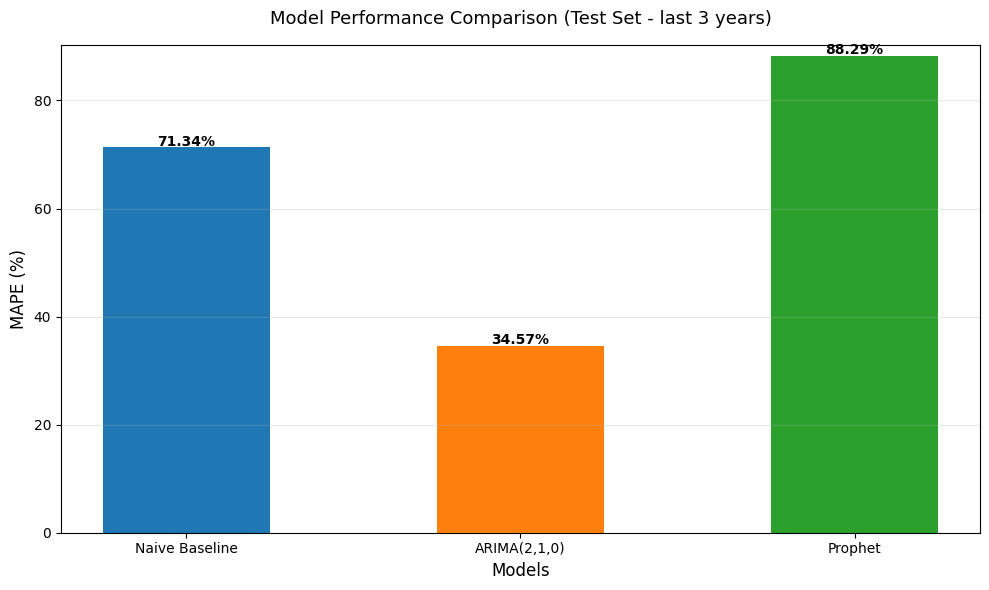

In [0]:
#plot
fig, ax = plt.subplots(figsize=(10, 6))

x = ['Naive Baseline', f'ARIMA({p},{d},{q})', 'Prophet']
y = [mape_naive_baseline, mape_ARIMA, mape_Prophet]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
ax.bar(x, y, width=0.5, color=colors)
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_ylim(0, max(y) + 2)
ax.set_title('Model Performance Comparison (Test Set - last 3 years)', fontsize=13, pad=15)
ax.grid(True, alpha=0.3, axis='y')

for index, value in enumerate(y):
    plt.text(x=index, y=value + 0.3, s=str(round(value,2)) + '%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()

ARIMA outperforms the rests. MAPE of 20-50% can be intepreted as reasonable forecasting.

Prophet and the naive method may struggle with this particular dataset, likely because, the annual oil consumption data may not have strong seasonal patterns that Prophet typically exploits.

In [0]:
#display the train dataframe
# display(train)

# Use the winning model (out of ARIMA or Prophet) to plot and save the 6-year forecast, including confidence intervals

In [0]:
# Retrain BOTH models on the entire dataset for final 6-year forecast
# This ensures both models use all available data for the production forecast

print("Retraining ARIMA on full dataset...")
if exogenous_variables is not None:
    exog_full = exogenous_variables[:len(df_pd)]
    ARIMA_full_model = SARIMAX(df_pd['Oil_Consumption'], exog=exog_full, order=(p,d,q), seasonal_order=(P,D,Q,s), simple_differencing=False, trend="c")
else:
    ARIMA_full_model = SARIMAX(df_pd['Oil_Consumption'], order=(p,d,q), seasonal_order=(P,D,Q,s), simple_differencing=False, trend="c")

ARIMA_full_model_fit = ARIMA_full_model.fit(disp=False, maxiter=500)
print("✓ ARIMA retrained")

# Retrain Prophet on full dataset too
print("\nRetraining Prophet on full dataset...")
prophet_full_df = df_pd[['Year', 'Oil_Consumption']].copy()
prophet_full_df.columns = ['ds', 'y']
prophet_full_df['ds'] = pd.to_datetime(prophet_full_df['ds'].astype(str) + '-01-01')

# Add exogenous variable to full Prophet training data (if available)
if exogenous_variables is not None:
    prophet_full_df['exog_scenario'] = exogenous_variables[:len(df_pd)]

# Initialize and fit Prophet model on FULL dataset
model_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

if exogenous_variables is not None:
    model_full.add_regressor('exog_scenario')

model_full.fit(prophet_full_df)
print("✓ Prophet retrained")

# Generate Prophet forecast for 6 years using the FULL model
future_full = model_full.make_future_dataframe(periods=6, freq='YS')
if exogenous_variables is not None:
    # Pad exogenous_variables if needed to match future_full length
    exog_for_future_full = list(exogenous_variables) + [exogenous_variables[-1]] * (len(future_full) - len(exogenous_variables))
    future_full['exog_scenario'] = exog_for_future_full[:len(future_full)]

forecast_full = model_full.predict(future_full)
print("✓ Prophet forecast generated from full model")

# Forecast for the next 6 years
if exogenous_variables is not None:
    # Pad exogenous_variables if needed for the forecast period
    exog_needed = len(df_pd) + 6
    exog_padded = list(exogenous_variables) + [exogenous_variables[-1]] * max(0, exog_needed - len(exogenous_variables))
    exog_forecast = exog_padded[len(df_pd):exog_needed]
    ARIMA_forecast = ARIMA_full_model_fit.get_forecast(6, exog=exog_forecast)
else:
    ARIMA_forecast = ARIMA_full_model_fit.get_forecast(6)
ARIMA_forecast_conf = ARIMA_forecast.conf_int(alpha=0.05)
ARIMA_forecast_df = pd.concat([ARIMA_forecast.predicted_mean, ARIMA_forecast_conf], axis=1)
ARIMA_forecast_df.columns = ['ARIMA_forecast', 'ARIMA_forecast_lower', 'ARIMA_forecast_upper']

# Generate proper year range for the forecast (dynamic, based on last year)
last_year = int(df_pd['Year'].iloc[-1])
forecast_years = pd.date_range(start=f'{last_year+1}-01-01', periods=len(ARIMA_forecast_df), freq='YS')
ARIMA_forecast_df.index = forecast_years

# Convert historical years to datetime for consistent plotting
df_pd_plot = df_pd.copy()
df_pd_plot['Year'] = pd.to_datetime(df_pd_plot['Year'].astype(str) + '-01-01')


Retraining ARIMA on full dataset...
✓ ARIMA retrained

Retraining Prophet on full dataset...


10:06:47 - cmdstanpy - INFO - Chain [1] start processing
10:06:47 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet retrained
✓ Prophet forecast generated from full model


In [0]:
# Select the best model based on MAPE
if mape_Prophet < mape_ARIMA:
    print(f"✓ Prophet selected as best model (MAPE: {mape_Prophet:.2f}% vs ARIMA: {mape_ARIMA:.2f}%)")
    winning_model = 'Prophet'
    winning_mape = mape_Prophet
    
    # Prepare Prophet forecast dataframe (6 years beyond FULL dataset, not just training)
    # Use forecast_full which was generated from the model retrained on full data
    last_full_year = pd.to_datetime(str(int(df_pd['Year'].iloc[-1])) + '-01-01')
    forecast_future = forecast_full[forecast_full['ds'] > last_full_year].copy()
    best_forecast_df = pd.DataFrame({
        'Year': forecast_future['ds'],
        'Forecast': forecast_future['yhat'],
        'Forecast_Lower': forecast_future['yhat_lower'],
        'Forecast_Upper': forecast_future['yhat_upper']
    }).reset_index(drop=True)
else:
    print(f"✓ ARIMA selected as best model (MAPE: {mape_ARIMA:.2f}% vs Prophet: {mape_Prophet:.2f}%)")
    winning_model = 'ARIMA'
    winning_mape = mape_ARIMA
    
    # Prepare ARIMA forecast dataframe
    best_forecast_df = pd.DataFrame({
        'Year': ARIMA_forecast_df.index,
        'Forecast': ARIMA_forecast_df['ARIMA_forecast'],
        'Forecast_Lower': ARIMA_forecast_df['ARIMA_forecast_lower'],
        'Forecast_Upper': ARIMA_forecast_df['ARIMA_forecast_upper']
    }).reset_index(drop=True)

# IMPORTANT: Clip forecast values to ensure they never go below 0
# Oil consumption cannot be negative
best_forecast_df['Forecast'] = best_forecast_df['Forecast'].clip(lower=0)
best_forecast_df['Forecast_Lower'] = best_forecast_df['Forecast_Lower'].clip(lower=0)
best_forecast_df['Forecast_Upper'] = best_forecast_df['Forecast_Upper'].clip(lower=0)

print(f"\nForecast details:")
print(f"  Periods: {len(best_forecast_df)} years")
print(f"  Year range: {best_forecast_df['Year'].min()} to {best_forecast_df['Year'].max()}")
print(f"  Final forecast value: {best_forecast_df['Forecast'].iloc[-1]:.2f} kbpd")

# Prepare historical data with NULL forecast column
hist_df = df_pd_plot[['Year', 'Oil_Consumption']].copy()
hist_df['Forecast'] = None
hist_df['Forecast_Lower'] = None
hist_df['Forecast_Upper'] = None

# Prepare forecast data with NULL historical column
forecast_df = best_forecast_df.copy()
forecast_df['Oil_Consumption'] = None

# Combine historical and forecast data
base_timeseries_df = pd.concat([hist_df, forecast_df], ignore_index=True)
base_timeseries_df = base_timeseries_df.sort_values(by='Year').reset_index(drop=True)

# Add Country and Scenario columns, rename to match table schema
base_timeseries_df['Country'] = f'{country}'
base_timeseries_df['Scenario'] = scenario_sanitized

# Rename columns to match target table schema
base_timeseries_df = base_timeseries_df.rename(columns={
    'Year': 'Date',
    'Oil_Consumption': 'Total_crude',
    'Forecast': 'Total_crude_forecast',
    'Forecast_Lower': 'Total_Lower_Bound',
    'Forecast_Upper': 'Total_Upper_Bound'
})

# Reorder columns to match table schema
base_timeseries_df = base_timeseries_df[['Country', 'Scenario', 'Date', 'Total_crude', 'Total_crude_forecast', 'Total_Lower_Bound', 'Total_Upper_Bound']]

# Save to table, & replace existing data for this country+scenario
print(f"\nSaving forecast to table: workspace.gold.consumption_forecast_table_annual")

#---------------------------------------------------------------#
# Add the Total_crude_forecast column if it doesn't exist
try:
    spark.sql("""
        ALTER TABLE workspace.gold.consumption_forecast_table_annual
        ADD COLUMN Total_crude_forecast DOUBLE
    """)
    print("  Added Total_crude_forecast column to table")
except Exception as e:
    if "already exists" not in str(e).lower():
        raise
#---------------------------------------------------------------#

# Delete existing entries for this country+scenario
print(f"  Deleting existing entries for {country} + {scenario_sanitized}...")
spark.sql(f"""
    DELETE FROM workspace.gold.consumption_forecast_table_annual
    WHERE Country = '{country}' AND Scenario = '{scenario_sanitized}'
""")

# Insert new data
spark.createDataFrame(base_timeseries_df).write.mode('append').saveAsTable(f'workspace.gold.consumption_forecast_table_annual')
print("✓ Forecast saved successfully to consumption_forecast_table_annual!")

✓ ARIMA selected as best model (MAPE: 34.57% vs Prophet: 88.29%)

Forecast details:
  Periods: 6 years
  Year range: 2025-01-01 00:00:00 to 2030-01-01 00:00:00
  Final forecast value: 0.00 kbpd

Saving forecast to table: workspace.gold.consumption_forecast_table_annual


/home/spark-9377e451-9913-4e69-bf87-73/.ipykernel/93/command-8195117642548370-2335727469:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_timeseries_df = pd.concat([hist_df, forecast_df], ignore_index=True)


  Deleting existing entries for Canada + covid_shutdowns...
✓ Forecast saved successfully to consumption_forecast_table_annual!


In [0]:
#display the forecast table for validation
display(spark.sql(f"select * from workspace.gold.consumption_forecast_table_annual"))

Country,Scenario,Date,Total_crude,Total_Lower_Bound,Total_Upper_Bound,Total_crude_forecast,generic_name,event_direction
United States,baseline_scenario,1980-01-01T00:00:00.000Z,2508.267822265625,null,null,null,null,baseline
United States,baseline_scenario,1981-01-01T00:00:00.000Z,2087.75341796875,null,null,null,null,baseline
United States,baseline_scenario,1982-01-01T00:00:00.000Z,1716.462890625,null,null,null,null,baseline
United States,baseline_scenario,1983-01-01T00:00:00.000Z,1420.833984375,null,null,null,null,baseline
United States,baseline_scenario,1984-01-01T00:00:00.000Z,1369.396728515625,null,null,null,null,baseline
United States,baseline_scenario,1985-01-01T00:00:00.000Z,1202.301513671875,null,null,null,null,baseline
United States,baseline_scenario,1986-01-01T00:00:00.000Z,1418.4024658203125,null,null,null,null,baseline
United States,baseline_scenario,1987-01-01T00:00:00.000Z,1264.39404296875,null,null,null,null,baseline
United States,baseline_scenario,1988-01-01T00:00:00.000Z,1377.800048828125,null,null,null,null,baseline
United States,baseline_scenario,1989-01-01T00:00:00.000Z,1370.0472412109375,null,null,null,null,baseline


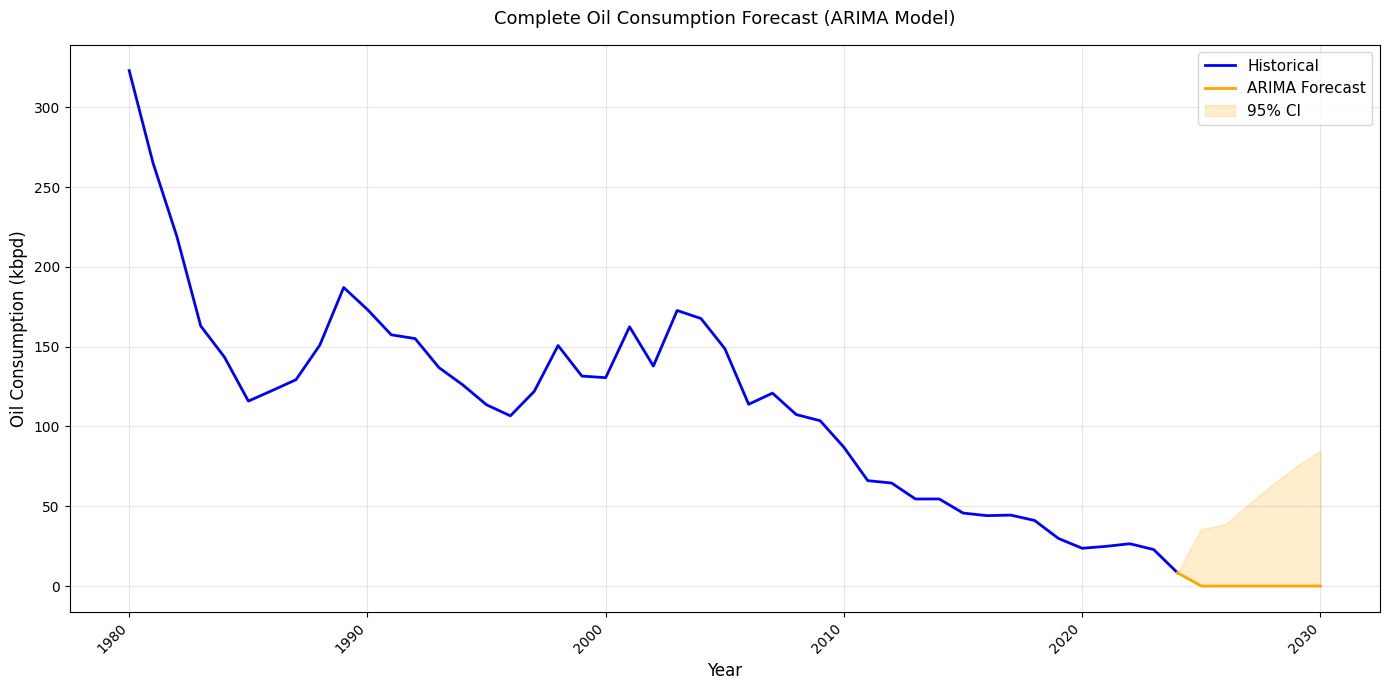


FORECAST VALIDATION SUMMARY
Winning Model: ARIMA
Historical data ends: 2024
Forecast extends to: 2030
Final forecast value: 0.00 kbpd
95% CI: [0.00, 84.76] kbpd


In [0]:
# Plot complete timeseries with confidence intervals
plot_df = spark.sql(f"select * from workspace.gold.consumption_forecast_table_annual WHERE Country = '{country}' AND Scenario = '{scenario_sanitized}'").toPandas()
plot_df['Date'] = pd.to_datetime(plot_df['Date'])
last_hist_year = pd.to_datetime(df_pd_plot['Year'].iloc[-1])

# Split into historical and forecast
hist = plot_df[plot_df['Date'] <= last_hist_year]
forecast = plot_df[plot_df['Date'] > last_hist_year]

# Create connection dataframe for smooth plotting (last historical + forecast)
last_hist_point = hist.iloc[-1:].copy()
last_hist_point['Total_crude_forecast'] = last_hist_point['Total_crude']  # Use historical value as connection
forecast_conn = pd.concat([last_hist_point, forecast])

# Fill CI bounds at connection point to avoid gaps
forecast_conn['Total_Lower_Bound'] = forecast_conn['Total_Lower_Bound'].fillna(forecast_conn['Total_crude_forecast'])
forecast_conn['Total_Upper_Bound'] = forecast_conn['Total_Upper_Bound'].fillna(forecast_conn['Total_crude_forecast'])

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(hist['Date'], hist['Total_crude'], color='blue', linewidth=2, label='Historical')
ax.plot(forecast_conn['Date'], forecast_conn['Total_crude_forecast'], color='orange', linewidth=2, label=f'{winning_model} Forecast')
ax.fill_between(forecast_conn['Date'], forecast_conn['Total_Lower_Bound'], forecast_conn['Total_Upper_Bound'], color='orange', alpha=0.2, label='95% CI')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Oil Consumption (kbpd)', fontsize=12)
ax.set_title(f'Complete Oil Consumption Forecast ({winning_model} Model)', fontsize=13, pad=15)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}\nFORECAST VALIDATION SUMMARY\n{'='*60}")
print(f"Winning Model: {winning_model}")
print(f"Historical data ends: {last_hist_year.strftime('%Y')}")
print(f"Forecast extends to: {forecast['Date'].max().strftime('%Y')}")
print(f"Final forecast value: {forecast['Total_crude_forecast'].iloc[-1]:.2f} kbpd")
print(f"95% CI: [{forecast['Total_Lower_Bound'].iloc[-1]:.2f}, {forecast['Total_Upper_Bound'].iloc[-1]:.2f}] kbpd")
print(f"{'='*60}")

In [0]:
# Extract the coefficient of the exogenous variable from the winning model (if exog is used)
if exogenous_variables is not None:
    print(f"\n{'='*60}")
    print(f"EXOGENOUS VARIABLE COEFFICIENT ANALYSIS")
    print(f"{'='*60}")
    print(f"Scenario: {scenario}")
    print(f"Model: {winning_model}")
    
    if winning_model == 'ARIMA':
        # For ARIMA, the exog coefficient is in the params
        # The first exogenous variable is typically labeled as 'x1'
        params = ARIMA_full_model_fit.params
        if 'x1' in params.index:
            exog_coef = params['x1']
            print(f"\nExogenous Variable Coefficient: {exog_coef:.6f}")
            print(f"\nInterpretation:")
            if exog_coef > 0:
                print(f"  → Positive coefficient: The scenario event is associated with an INCREASE in oil production")
                print(f"  → A 1-unit increase in the scenario variable increases production by ~{exog_coef:.2f} kbpd")
            else:
                print(f"  → Negative coefficient: The scenario event is associated with a DECREASE in oil production")
                print(f"  → A 1-unit increase in the scenario variable decreases production by ~{abs(exog_coef):.2f} kbpd")
        else:
            print("\nWarning: Exogenous coefficient 'x1' not found in model parameters")
            print(f"Available parameters: {params.index.tolist()}")
            print("\nThis means the exogenous variable had insufficient variation and was excluded from the model.")
            print("Setting coefficient to 0 (no impact).")
            exog_coef = 0  # Set to 0 when model excluded the exogenous variable
    
    elif winning_model == 'Prophet':
        # For Prophet, regressor coefficients are stored in the 'beta' array in model.params
        # The beta array contains: [seasonality_coefficients..., regressor_coefficients...]
        # Regressors are at the end of the beta array
        # Use model_full which was retrained on the full dataset
        
        if len(model_full.extra_regressors) > 0:
            beta_array = model_full.params['beta'][0]  # Extract from (1, n) shape to (n,) array
            # The regressor coefficient is at index -(number of regressors)
            regressor_index = -len(model_full.extra_regressors)
            exog_coef = beta_array[regressor_index]
            
            print(f"\nExogenous Variable Coefficient: {exog_coef:.6f}")
            print(f"\nInterpretation:")
            if exog_coef > 0:
                print(f"  → Positive coefficient: The scenario event is associated with an INCREASE in oil production")
                print(f"  → The scenario adds approximately {exog_coef:.2f} kbpd to the baseline forecast")
            else:
                print(f"  → Negative coefficient: The scenario event is associated with a DECREASE in oil production")
                print(f"  → The scenario reduces approximately {abs(exog_coef):.2f} kbpd from the baseline forecast")
        else:
            print("\nWarning: No exogenous regressors found in Prophet model")
            print("Setting coefficient to 0 (no impact).")
            exog_coef = 0  # Set to 0 when model excluded the exogenous variable
    
    print(f"{'='*60}")
    
    # Always update the coefficient to workspace.gold.exogenous_variables table
    print(f"\nSaving coefficient to workspace.gold.exogenous_variables...")

    spark.sql(f"""
        UPDATE workspace.gold.exogenous_variables
        SET Coefficient = {exog_coef}
        WHERE Country = '{country}' AND Description = '{scenario}'
    """)
    
    print(f"✓ Coefficient {exog_coef:.6f} saved for {country} - {scenario}")
    print(f"{'='*60}")
else:
    print("\nNo exogenous variable used (Baseline scenario)")



EXOGENOUS VARIABLE COEFFICIENT ANALYSIS
Scenario: COVID Shutdowns
Model: ARIMA

Exogenous Variable Coefficient: -11.111575

Interpretation:
  → Negative coefficient: The scenario event is associated with a DECREASE in oil production
  → A 1-unit increase in the scenario variable decreases production by ~11.11 kbpd

Saving coefficient to workspace.gold.exogenous_variables...
✓ Coefficient -11.111575 saved for Canada - COVID Shutdowns


###Record model metrics to table

In [0]:
#Save model run metrics to gold.model_metrics, replacing other model runs for this Country+Scenario+Direction combination

#Add parameters to winning_model if model is ARIMA
if winning_model == 'ARIMA':
    winning_model = f'ARIMA({p},{d},{q})'

# Initialize exog_coef if not already set (for baseline scenarios or when coefficient wasn't found)
if 'exog_coef' not in locals():
    exog_coef = 0

#if it doesn't exist, create table model_metrics
spark.sql(f"""
    CREATE TABLE IF NOT EXISTS workspace.gold.model_metrics (
        Country string,
        Scenario string,
        Direction string,
        Date_of_run TIMESTAMP,
        Best_model string,
        MAPE string,
        Coefficient DOUBLE
    )
""")

# Delete existing entry for this Country+Scenario+Direction combination
spark.sql(f"""
    DELETE FROM workspace.gold.model_metrics
    WHERE Country = '{country}' 
      AND Scenario = '{scenario_sanitized}' 
      AND Direction = 'Consumption'
""")

# Insert new model run metrics
spark.sql(f"""
    INSERT INTO workspace.gold.model_metrics (Country, Scenario, Direction, Best_model, MAPE, Date_of_run, Coefficient)
    VALUES ('{country}', '{scenario_sanitized}', 'Consumption', '{winning_model}', '{winning_mape:.2f}', '{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}', {exog_coef})
""")


DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]

In [0]:
# Calculate total execution time
notebook_end_time = time.time()
total_seconds = notebook_end_time - notebook_start_time

# Format the output
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print("="*50)
print(f"Notebook execution completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total execution time: {minutes} minutes and {seconds} seconds")
print(f"Total execution time: {total_seconds:.2f} seconds")
print("="*50)

Notebook execution completed at: 2026-08-27 10:07:31
Total execution time: 1 minutes and 13 seconds
Total execution time: 73.28 seconds
